# Kickstarter projects

В чем суть: есть проекты на кикстертере, мы хотим предсказать на этапе инвестирования, будет ли проект успешным

Почему этот датасет: далее в проекте будут временные ряды, можно привязать энкодеры или ллм на текстовые фичи

Плюс, есть интересная фича usd_goal_real, можно тянуть апишку и вычилсять в реальном времени

Чтобы ноутбук запустился, его нужно поместить в корень проекта! Не в папку notebboks

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
SEED = 42

In [2]:
df = pd.read_csv("data/ks-projects-201801.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   currency          378661 non-null  object 
 5   deadline          378661 non-null  object 
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  object 
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  object 
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  object 
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), object(8)
memory usage: 43.3+ MB


In [3]:
df.head()

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


## Таргет

берем бинарную классификацию: successful и failed

In [4]:
df = df[df['state'].isin(['successful', 'failed'])]
df['target'] = (df['state'] == 'successful').astype(int)
df.shape

(331675, 16)

In [5]:
rate = df["target"].mean()
print(f"{df['target'].sum()} из {len(df)} ({rate:.1%})")
df["target"].value_counts()

133956 из 331675 (40.4%)


target
0    197719
1    133956
Name: count, dtype: int64

## Target-leak

убираем target-leak фичи, их не будет на инференсе

In [6]:
df = df.drop(columns=['ID', 'pledged', 'backers', 'state', 'usd pledged', 'usd_pledged_real'])


## Пропуски

Пропуски только в имени проекта, оставим как фичу

In [7]:
missing_pct = df.isnull().mean() * 100
missing_pct

name             0.000904
category         0.000000
main_category    0.000000
currency         0.000000
deadline         0.000000
goal             0.000000
launched         0.000000
country          0.000000
usd_goal_real    0.000000
target           0.000000
dtype: float64

## Train Test

Сделаем колонку для сортировки, а потом удалим чтобы не потрить пайплайн

На фолдах разное соотношение положительного/отрицательного класса, но делать я с этим ничего не буду пока не дойду до временных рядов. заодно можно будет поработать с разными версиями моделей

In [8]:
df["sort"] = pd.to_datetime(df["launched"])
df = df.sort_values(by="sort", ascending=True)
df = df.reset_index(drop=True)

In [9]:
X = df.drop(columns=["target", "sort"])
y = df["target"]

In [10]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(X):
    print(f"Train: {train_idx[0]}-{train_idx[-1]}, Test: {test_idx[0]}-{test_idx[-1]}")

    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    rate = y_train_fold.mean()
    print(f"{y_train_fold.sum()} из {len(y_train_fold)} ({rate:.1%})")
    print(y_train_fold.value_counts())

    rate = y_test_fold.mean()
    print(f"{y_test_fold.sum()} из {len(y_test_fold)} ({rate:.1%})")
    print(y_test_fold.value_counts())
    print()

Train: 0-55279, Test: 55280-110558
26983 из 55280 (48.8%)
target
0    28297
1    26983
Name: count, dtype: int64
25984 из 55279 (47.0%)
target
0    29295
1    25984
Name: count, dtype: int64

Train: 0-110558, Test: 110559-165837
52967 из 110559 (47.9%)
target
0    57592
1    52967
Name: count, dtype: int64
20269 из 55279 (36.7%)
target
0    35010
1    20269
Name: count, dtype: int64

Train: 0-165837, Test: 165838-221116
73236 из 165838 (44.2%)
target
0    92602
1    73236
Name: count, dtype: int64
17428 из 55279 (31.5%)
target
0    37851
1    17428
Name: count, dtype: int64

Train: 0-221116, Test: 221117-276395
90664 из 221117 (41.0%)
target
0    130453
1     90664
Name: count, dtype: int64
20102 из 55279 (36.4%)
target
0    35177
1    20102
Name: count, dtype: int64

Train: 0-276395, Test: 276396-331674
110766 из 276396 (40.1%)
target
0    165630
1    110766
Name: count, dtype: int64
23190 из 55279 (42.0%)
target
0    32089
1    23190
Name: count, dtype: int64



In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331675 entries, 0 to 331674
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   name           331672 non-null  object 
 1   category       331675 non-null  object 
 2   main_category  331675 non-null  object 
 3   currency       331675 non-null  object 
 4   deadline       331675 non-null  object 
 5   goal           331675 non-null  float64
 6   launched       331675 non-null  object 
 7   country        331675 non-null  object 
 8   usd_goal_real  331675 non-null  float64
dtypes: float64(2), object(7)
memory usage: 22.8+ MB


In [12]:
date_columns = ["deadline", "launched"]
text_columns = ["name"]
num_columns = ["goal", "usd_goal_real"]
obj_columns = ["category", "main_category", "currency", "country"]

## Предобработка времени, временные фичи

In [13]:
# import numpy as np
# import pandas as pd
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.compose import ColumnTransformer


# class DateFeatureExtractor(BaseEstimator, TransformerMixin):
#     def __init__(self, date_cols=None):
#         self.date_cols = date_cols

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):
#         if isinstance(X, pd.DataFrame):
#             X_out = X.copy()
#         else:
#             X_out = pd.DataFrame(X, columns=self.date_cols)

#         for col in X_out.columns:
#             dt_series = pd.to_datetime(X_out[col], errors="coerce")

#             X_out[f"{col}_year"] = dt_series.dt.year
#             X_out[f"{col}_month"] = dt_series.dt.month
#             X_out[f"{col}_day"] = dt_series.dt.day
#             X_out[f"{col}_dayofweek"] = dt_series.dt.dayofweek

#             X_out = X_out.drop(columns=[col])

#         return X_out


## Предобработка текстовых фичей

In [14]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# class SqueezedTfidfVectorizer(TfidfVectorizer):
#     def fit(self, X, y=None):
#         return super().fit(X.ravel(), y)

#     def fit_transform(self, X, y=None):
#         return super().fit_transform(X.ravel(), y)

#     def transform(self, X):
#         return super().transform(X.ravel())

In [15]:
from src.kickstarter.service.transformers import (
       DateFeatureExtractor,
       SqueezedTfidfVectorizer,
   )

In [16]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())]), 
            num_columns,
        ),
        (
            "cat",
            Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
            obj_columns,
        ),
        (
            "text",
            Pipeline([("impute",
                        SimpleImputer(strategy="constant", fill_value="")),
                    ("tfidf", SqueezedTfidfVectorizer(max_features=1000))]),
            text_columns,
        ),
        (
            "date",
            Pipeline([("extract_dates",
                        DateFeatureExtractor(date_cols=date_columns)),
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())]),
            date_columns,
        ),
    ],
    remainder="drop",
)

## Baseline logreg

In [17]:
def report(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    row = {
        "model": name,
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        f"precision@{threshold}": precision_score(y_true, pred),
        f"recall@{threshold}": recall_score(y_true, pred),
        f"F1@{threshold}": f1_score(y_true, pred),
    }
    return row

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_auc_score, precision_score, recall_score, f1_score)

fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    model = Pipeline(
        [
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=1000, C=1.0)),
        ]
    )
    model.fit(X_train_fold, y_train_fold)

    proba = model.predict_proba(X_test_fold)[:, 1]

    fold_row = report(f"logreg_fold_{fold + 1}", y_test_fold, proba)
    fold_metrics.append(fold_row)

df_folds = pd.DataFrame(fold_metrics)

mean_scores = df_folds.drop(columns=["model"]).mean().to_dict()
mean_scores["model"] = "logreg_mean"
df_folds = pd.concat(
    [df_folds, pd.DataFrame([mean_scores])], ignore_index=True
)

df_folds.round(3)

d:\projects\ml_service\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
d:\projects\ml_service\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
d:\projects\ml_service\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
d:\projects\ml_service\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
d:\projects\ml_service\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg_fold_1,0.699,0.663,0.650,0.530,0.584
1,logreg_fold_2,0.594,0.414,0.444,0.633,0.522
2,logreg_fold_3,0.738,0.562,0.606,0.395,0.478
3,logreg_fold_4,0.745,0.615,0.685,0.319,0.436
4,logreg_fold_5,0.747,0.666,0.708,0.373,0.488
5,logreg_mean,0.705,0.584,0.619,0.450,0.502


## Финальное обучение

In [19]:
final_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=42))
]).fit(X, y)


d:\projects\ml_service\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## PR кривая и модель кривая

Возьмем за основную метрику Precision так как инвесторы боятся FP срабатываний. Пусть модель угадывает 70% плохих проектов

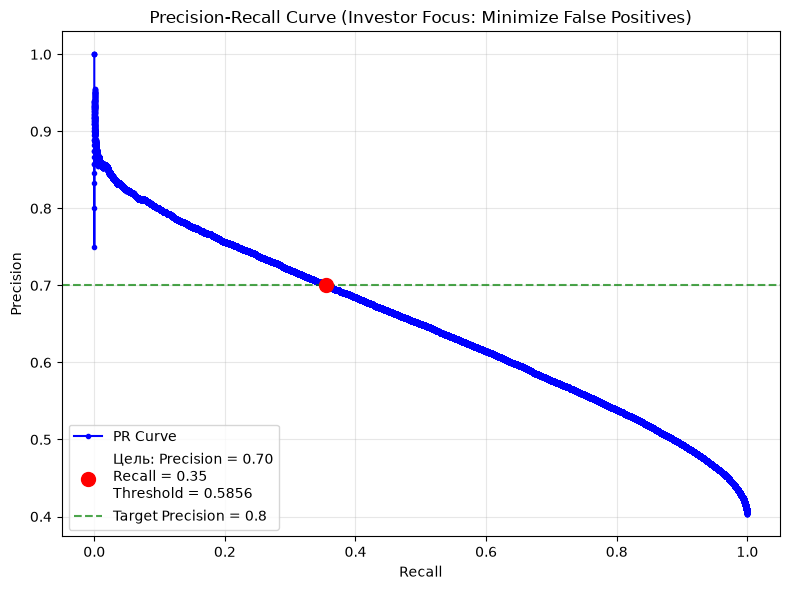

In [20]:
proba_full = final_model.predict_proba(X)[:, 1]
precision, recall, thresholds = precision_recall_curve(y, proba_full)

mask = precision >= 0.7
target_precision, target_recall, target_threshold = None, None, None

if np.any(mask):
    idx = np.where(mask)[0][0]
    target_precision = precision[idx]
    target_recall = recall[idx]
    target_threshold = thresholds[idx - 1] if idx > 0 else thresholds[0]

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='PR Curve', color='blue')

if target_precision is not None:
    plt.scatter([target_recall], [target_precision], color='red', zorder=5, s=100,
                label=f'Цель: Precision = {target_precision:.2f}\nRecall = {target_recall:.2f}\nThreshold = {target_threshold:.4f}')
    plt.axhline(0.7, color='green', linestyle='--', alpha=0.7, label='Target Precision = 0.8')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Investor Focus: Minimize False Positives)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Артефакт

In [24]:
from pathlib import Path
import sklearn
import joblib
import json

ARTIFACTS = Path("artifact")
ARTIFACTS.mkdir(exist_ok=True)

metrics_for_meta = {
    "ROC-AUC": float(mean_scores.get("ROC-AUC", 0.0)),
    "PR-AUC": float(mean_scores.get("PR-AUC", 0.0)),
    "precision@0.5": float(mean_scores.get("precision@0.5", 0.0)),
    "recall@0.5": float(mean_scores.get("recall@0.5", 0.0)),
    "F1@0.5": float(mean_scores.get("F1@0.5", 0.0))
}

best_threshold = float(target_threshold) if target_threshold is not None else 0.5

num_cols = num_columns if 'num_columns' in globals() else []
cat_cols = obj_columns if 'obj_columns' in globals() else []
date_cols = date_columns if 'date_columns' in globals() else []
text_cols = text_columns if 'text_columns' in globals() else []


metadata = {
    "model_name": "kickstarter-logreg",
    "model_version": "0.1.0",
    "trained_at": pd.Timestamp.utcnow().isoformat(timespec="seconds"),
    "n_train": int(len(X)),
    "features": list(X.columns),
    "numeric_cols": num_cols,
    "categorical_cols": cat_cols,
    "text_cols": text_cols,
    "date_cols": date_cols,
    "threshold": float(round(best_threshold, 4)),
    "metrics_test": {k: round(float(v), 4) for k, v in metrics_for_meta.items()},
    "libs": {
        "pandas": pd.__version__, 
        "scikit-learn": sklearn.__version__
    },
}

joblib.dump({
    "pipeline": final_model, 
    "metadata": metadata
}, ARTIFACTS / "model.joblib")

(ARTIFACTS / "metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), 
    encoding="utf-8"
)

print("Сохраненные артефакты:")
print(sorted([p.name for p in ARTIFACTS.iterdir()]))

Сохраненные артефакты:
['metadata.json', 'model.joblib']


## Тест

In [25]:
loaded_artifact = joblib.load(ARTIFACTS / "model.joblib")
loaded_pipeline = loaded_artifact["pipeline"]
loaded_metadata = loaded_artifact["metadata"]

sample_row = X.iloc[[0]]
true_label = y.iloc[0]

pred_proba = loaded_pipeline.predict_proba(sample_row)[0, 1]
pred_class = int(pred_proba >= loaded_metadata["threshold"])

print(f"Истинный класс: {true_label}")
print(f"Предсказанная вероятность: {pred_proba:.4f}")
print(f"Порог из метаданных (threshold): {loaded_metadata['threshold']}")
print(f"Предсказанный класс: {pred_class}")
print(f"Название модели из метаданных: {loaded_metadata['model_name']}")

Истинный класс: 0
Предсказанная вероятность: 0.4080
Порог из метаданных (threshold): 0.5856
Предсказанный класс: 0
Название модели из метаданных: kickstarter-logreg
